# 01. Sparkov Data Quality Audit

This notebook performs an initial audit of the Sparkov credit card transaction dataset.

## Objectives

- inspect the dataset structure
- verify timestamps
- examine fraud prevalence
- inspect missing values and duplicates
- identify potential leakage risks
- prepare the dataset for chronological validation

No predictive model is trained in this notebook.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/priyamchoksi/credit-card-transactions-dataset/credit_card_transactions.csv


In [2]:
import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

SEED = 42
np.random.seed(SEED)

print("Setup complete.")

Setup complete.


In [3]:
os.makedirs("/kaggle/working/results", exist_ok=True)
os.makedirs("/kaggle/working/figures", exist_ok=True)

print("Output folders created.")

Output folders created.


In [4]:
def find_csv():
    candidates = []

    for dirname, _, filenames in os.walk("/kaggle/input"):
        for filename in filenames:
            if filename.endswith(".csv"):
                candidates.append(
                    os.path.join(dirname, filename)
                )

    return candidates


csv_files = find_csv()

for path in csv_files:
    print(path)

DATA_PATH = "/kaggle/input/datasets/priyamchoksi/credit-card-transactions-dataset/credit_card_transactions.csv"


/kaggle/input/datasets/priyamchoksi/credit-card-transactions-dataset/credit_card_transactions.csv


## 1. Load Dataset

In [5]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)

Shape: (1296675, 24)


In [6]:
display(df.head())


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


In [7]:
display(df.tail())

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
1296670,1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,Hatch,UT,84735,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0,NaN
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,Tuscarora,MD,21790,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0,22630.0
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,NM,88325,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0,88351.0
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,Manderson,SD,57756,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0,69367.0
1296674,1296674,2020-06-21 12:13:37,4292902571056973207,"fraud_Langosh, Wintheiser and Hyatt",food_dining,4.30,Jeffrey,Smith,M,135 Joseph Mountains,Sula,MT,59871,45.8433,-113.8748,218,"Therapist, horticultural",1995-08-16,8f7c8e4ab7f25875d753b422917c98c9,1371816817,46.565983,-114.186110,0,59870.0


In [8]:
print(df.columns.tolist())

['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode']


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

## 2. Basic Cleaning

In [10]:
unnamed_cols = [
    col for col in df.columns
    if col.lower().startswith("unnamed")
]

print("Columns to remove:", unnamed_cols)

df = df.drop(
    columns=unnamed_cols,
    errors="ignore"
)

print("Shape after removal:", df.shape)

Columns to remove: ['Unnamed: 0']
Shape after removal: (1296675, 23)


In [11]:
df["trans_date_trans_time"] = pd.to_datetime(
    df["trans_date_trans_time"],
    errors="coerce"
)

df["dob"] = pd.to_datetime(
    df["dob"],
    errors="coerce"
)

print(df["trans_date_trans_time"].dtype)
print(df["dob"].dtype)

datetime64[ns]
datetime64[ns]


In [12]:
df = (
    df.sort_values(
        ["unix_time", "trans_num"]
    )
    .reset_index(drop=True)
)

In [13]:
start_time = df["trans_date_trans_time"].min()
end_time = df["trans_date_trans_time"].max()

print("Start:", start_time)
print("End:", end_time)
print("Duration:", end_time - start_time)

Start: 2019-01-01 00:00:18
End: 2020-06-21 12:13:37
Duration: 537 days 12:13:19


In [14]:
fraud_count = int(df["is_fraud"].sum())
total_count = len(df)
fraud_rate = df["is_fraud"].mean()

print("Total transactions:", total_count)
print("Fraud transactions:", fraud_count)
print("Fraud rate:", fraud_rate)
print("Fraud rate (%):", fraud_rate * 100)

Total transactions: 1296675
Fraud transactions: 7506
Fraud rate: 0.005788651743883394
Fraud rate (%): 0.5788651743883394


In [15]:
class_counts = (
    df["is_fraud"]
    .value_counts()
    .rename_axis("is_fraud")
    .reset_index(name="count")
)

class_counts["percentage"] = (
    class_counts["count"]
    / len(df)
    * 100
)

display(class_counts)

class_counts.to_csv(
    "/kaggle/working/results/class_distribution.csv",
    index=False
)

,is_fraud,count,percentage
0,0,1289169,99.421135
1,1,7506,0.578865


## 3. Missing Values

In [16]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_rate": df.isna().mean()
})

missing = (
    missing
    .sort_values(
        "missing_rate",
        ascending=False
    )
)

display(missing)

missing.to_csv(
    "/kaggle/working/results/missing_values.csv"
)

,missing_count,missing_rate
merch_zipcode,195973,0.151135
cc_num,0,0.000000
trans_date_trans_time,0,0.000000
category,0,0.000000
amt,0,0.000000
first,0,0.000000
merchant,0,0.000000
last,0,0.000000
gender,0,0.000000
city,0,0.000000


## 4. Duplicate Audit

In [17]:
complete_duplicates = df.duplicated().sum()
transaction_id_duplicates = (
    df["trans_num"].duplicated().sum()
)

print(
    "Complete duplicate rows:",
    complete_duplicates
)

print(
    "Duplicate transaction IDs:",
    transaction_id_duplicates
)

Complete duplicate rows: 0
Duplicate transaction IDs: 0


In [18]:
unique_cards = df["cc_num"].nunique()
unique_merchants = df["merchant"].nunique()
unique_categories = df["category"].nunique()

print("Unique cards:", unique_cards)
print("Unique merchants:", unique_merchants)
print("Unique categories:", unique_categories)

Unique cards: 983
Unique merchants: 693
Unique categories: 14


In [19]:
transactions_per_card = (
    df.groupby("cc_num")
      .size()
      .describe()
)

display(transactions_per_card)

transactions_per_merchant = (
    df.groupby("merchant")
      .size()
      .describe()
)

display(transactions_per_merchant)

count     983.000000
mean     1319.099695
std       812.235900
min         7.000000
25%       525.000000
50%      1054.000000
75%      2025.000000
max      3123.000000
dtype: float64

count     693.000000
mean     1871.103896
std       575.359948
min       727.000000
25%      1592.000000
50%      1863.000000
75%      2345.000000
max      4403.000000
dtype: float64

In [20]:
display(
    df.groupby("is_fraud")["amt"]
      .describe()
)

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,67.667110,154.007971,1.00,9.6100,47.280,82.540,28948.90
1,7506.0,531.320092,390.560070,1.06,245.6625,396.505,900.875,1376.04


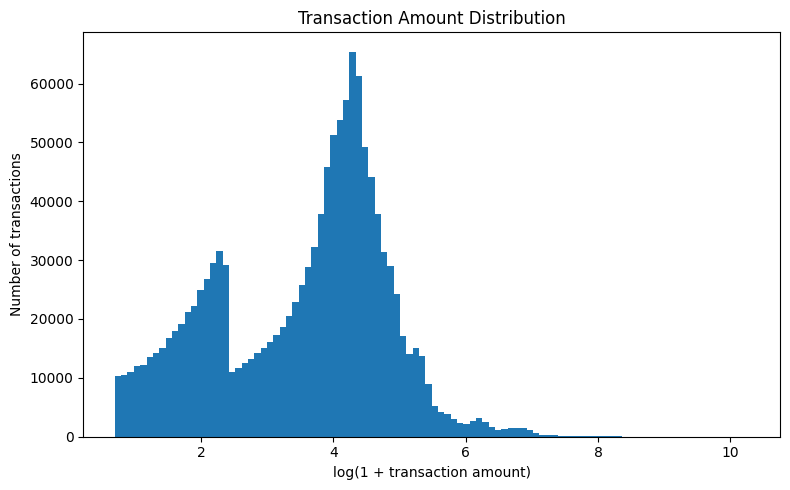

In [21]:
plt.figure(figsize=(8, 5))

plt.hist(
    np.log1p(df["amt"]),
    bins=100
)

plt.xlabel("log(1 + transaction amount)")
plt.ylabel("Number of transactions")
plt.title("Transaction Amount Distribution")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/amount_distribution.png",
    dpi=200
)

plt.show()

In [22]:
df["month"] = (
    df["trans_date_trans_time"]
    .dt.to_period("M")
    .astype(str)
)

monthly = (
    df.groupby("month")
      .agg(
          transactions=("is_fraud", "size"),
          frauds=("is_fraud", "sum"),
          fraud_rate=("is_fraud", "mean"),
          total_amount=("amt", "sum")
      )
      .reset_index()
)

display(monthly)

monthly.to_csv(
    "/kaggle/working/results/monthly_summary.csv",
    index=False
)

,month,transactions,frauds,fraud_rate,total_amount
0,2019-01,52525,506,0.009634,3759750.03
1,2019-02,49866,517,0.010368,3604662.23
2,2019-03,70939,494,0.006964,5027886.40
3,2019-04,68078,376,0.005523,4761504.58
4,2019-05,72532,408,0.005625,5060903.32
5,2019-06,86064,354,0.004113,6036397.42
6,2019-07,86596,331,0.003822,6044026.74
7,2019-08,87359,382,0.004373,6047288.65
8,2019-09,70652,418,0.005916,4949834.42
9,2019-10,68758,454,0.006603,4851267.37


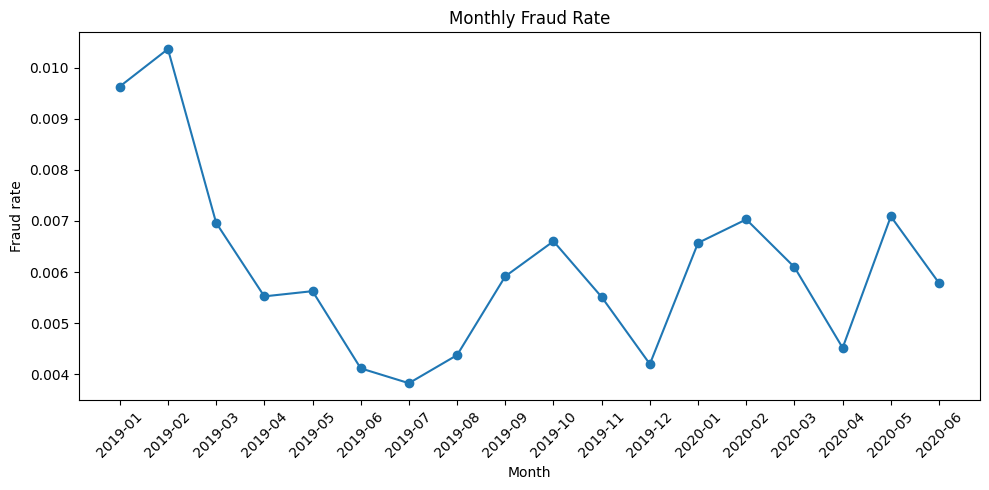

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly["month"],
    monthly["fraud_rate"],
    marker="o"
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Fraud rate")
plt.title("Monthly Fraud Rate")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/monthly_fraud_rate.png",
    dpi=200
)

plt.show()

,hour,transactions,frauds,fraud_rate
0,0,42502,635,0.014940
1,1,42869,658,0.015349
2,2,42656,625,0.014652
3,3,42769,609,0.014239
4,4,41863,46,0.001099
5,5,42171,60,0.001423
6,6,42300,40,0.000946
7,7,42203,56,0.001327
8,8,42505,49,0.001153
9,9,42185,47,0.001114


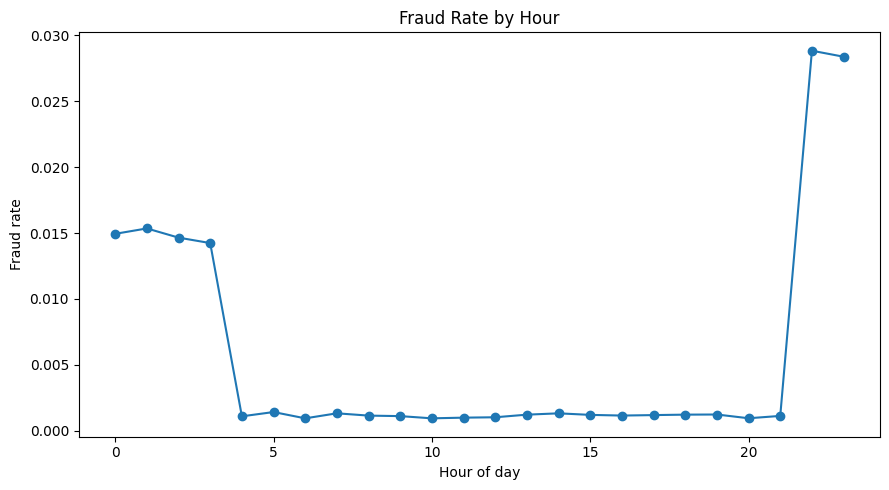

In [24]:
df["hour"] = (
    df["trans_date_trans_time"].dt.hour
)

hourly = (
    df.groupby("hour")
      .agg(
          transactions=("is_fraud", "size"),
          frauds=("is_fraud", "sum"),
          fraud_rate=("is_fraud", "mean")
      )
      .reset_index()
)

display(hourly)

plt.figure(figsize=(9, 5))

plt.plot(
    hourly["hour"],
    hourly["fraud_rate"],
    marker="o"
)

plt.xlabel("Hour of day")
plt.ylabel("Fraud rate")
plt.title("Fraud Rate by Hour")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/fraud_rate_by_hour.png",
    dpi=200
)

plt.show()

In [25]:
category_summary = (
    df.groupby("category")
      .agg(
          transactions=("is_fraud", "size"),
          frauds=("is_fraud", "sum"),
          fraud_rate=("is_fraud", "mean")
      )
      .sort_values(
          "fraud_rate",
          ascending=False
      )
      .reset_index()
)

display(category_summary)

category_summary.to_csv(
    "/kaggle/working/results/category_summary.csv",
    index=False
)

,category,transactions,frauds,fraud_rate
0,shopping_net,97543,1713,0.017561
1,misc_net,63287,915,0.014458
2,grocery_pos,123638,1743,0.014098
3,shopping_pos,116672,843,0.007225
4,gas_transport,131659,618,0.004694
5,misc_pos,79655,250,0.003139
6,grocery_net,45452,134,0.002948
7,travel,40507,116,0.002864
8,entertainment,94014,233,0.002478
9,personal_care,90758,220,0.002424


In [26]:
df["merchant_clean"] = (
    df["merchant"]
    .str.replace(
        r"^fraud_",
        "",
        regex=True
    )
)

display(
    df[
        ["merchant", "merchant_clean"]
    ].head()
)


,merchant,merchant_clean
0,"fraud_Rippin, Kub and Mann","Rippin, Kub and Mann"
1,"fraud_Heller, Gutmann and Zieme","Heller, Gutmann and Zieme"
2,fraud_Lind-Buckridge,Lind-Buckridge
3,"fraud_Kutch, Hermiston and Farrell","Kutch, Hermiston and Farrell"
4,fraud_Keeling-Crist,Keeling-Crist


In [27]:
summary = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "fraud_count",
        "fraud_rate",
        "unique_cards",
        "unique_merchants",
        "start_date",
        "end_date",
        "complete_duplicates",
        "transaction_id_duplicates",
    ],
    "value": [
        len(df),
        df.shape[1],
        int(df["is_fraud"].sum()),
        df["is_fraud"].mean(),
        df["cc_num"].nunique(),
        df["merchant_clean"].nunique(),
        df["trans_date_trans_time"].min(),
        df["trans_date_trans_time"].max(),
        df.duplicated().sum(),
        df["trans_num"].duplicated().sum(),
    ]
})

display(summary)

summary.to_csv(
    "/kaggle/working/results/data_summary.csv",
    index=False
)

,metric,value
0,rows,1296675
1,columns,26
2,fraud_count,7506
3,fraud_rate,0.005789
4,unique_cards,983
5,unique_merchants,693
6,start_date,2019-01-01 00:00:18
7,end_date,2020-06-21 12:13:37
8,complete_duplicates,0
9,transaction_id_duplicates,0


## Initial Findings

- The dataset contains temporally ordered credit card transactions.
- Fraud is highly imbalanced relative to legitimate transactions.
- Card and merchant identifiers allow historical behavioral features to be constructed.
- Transaction amount can later be used as a proxy for missed-fraud loss.
- All behavioral features must be constructed using only information available before each transaction.
- The next notebook will create chronological train, calibration, validation, and test periods before any model preprocessing is fitted.

## Important Limitation

Sparkov is a synthetic transaction dataset. Therefore, model performance should be interpreted as a methodological benchmark rather than as evidence of real-world bank performance.